# Image Clustering with K-Means (Week 6)





It all started with a few memes.

<p align="left">
<img src="screenshot.PNG" width="450">
<img src="Screenshot 2026-03-16 at 01.42.35.png" width="375">

</p>

I kept seeing memes online pointing out how similar AI company logos look. Once you notice it, it becomes impossible to ignore. Many of them use the same glowing gradients, abstract shapes and blue or purple colour palettes.

Interestingly this is something that also came up during branding discussions in design school. When new technology sectors appear, companies often end up adopting a similar visual language because they want to signal innovation, futurism or technical sophistication.

There is also an article by Radek Sienkiewicz called "Why Do AI Company Logos Look Like Buttholes?" on Velvet Shark which shows many of these logos side by side. Although the article highlights the similarity but it does not actually measure it.

Additionally, this was also ofcourse partly influenced by the reading "Algorithmic Ways of Seeing: Using Object Detection to Facilitate Art Exploration* by Meyer et al. (CHI 2024)", which explored how computer vision techniques reveal visual patterns across large image collections...



Personally I really liked the idea that algorithms can sometimes reveal relationships that are difficult to notice when images are examined individually.

So I wanted to test this idea on my own...If we run clustering on the logos and let the algorithm group them based purely on visual features, what happens?

So the core question I ended up exploring was:

"Do AI company logos cluster by product function, or do they collapse into a shared visual aesthetic regardless of what the product actually does?"

In [40]:
!pip install umap-learn torch torchvision scikit-learn matplotlib Pillow

## Dataset

For this experiment I collected a dataset of 128 AI company logos.

Most of them were downloaded automatically using a small Python script that fetched favicons through the Google favicon API. I ran the script using a list of company domains and saved each logo automatically.

Some logos had to be downloaded manually because the favicon resolution was too small.

To keep things organised I used the following naming format:

CompanyName__Category.png

The category label is only used later during analysis. The clustering algorithm never sees those labels.

This step took way longer than I expected...Some logos downloaded incorrectly and some companies only had wordmarks instead of icons. I decided to keep them anyway rather than over-clean the dataset.

In [41]:
import os

logo_folder = "logos"
files = os.listdir(logo_folder)

print(f"Found {len(files)} logos")
print(files[:5])

Found 128 logos
['Notion_AI__Productivity.png', 'Play_ht__Voice AI.png', 'Clipdrop__Image Editing.png', 'Natural_Reader__Voice AI.png', 'AssemblyAI__Voice AI.png']


## Preprocessing

### Extracting visual features

To cluster the logos I first needed to convert the images into numerical features.

For this I used "MobileNetV2" as a feature extractor. I removed the final classification layer and used the internal representation of each image as a feature vector.

One thing I was not completely sure about was whether a model trained on normal photographs would work well for logos or not? Logos are much simpler visually than typical ImageNet images so maybe...

But it seemed like a reasonable starting point so I decided to try it anyways.

In [42]:
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# Load MobileNet
print("Loading MobileNet")
model = models.mobilenet_v2(pretrained=True)
model.eval()

# Remove final classification layer to get features
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
feature_extractor.eval()

# Transform each image into the format MobileNet expects
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Extract features from every logo
print("Extracting features")
features = []
names = []
categories = []
image_paths = []

for filename in sorted(os.listdir(logo_folder)):
    if filename.endswith(".png"):
        path = os.path.join(logo_folder, filename)
        
        # Parse name and category from filename
        parts = filename.replace(".png", "").split("__")
        name = parts[0].replace("_", " ")
        category = parts[1] if len(parts) > 1 else "Unknown"
        
        # Extract features
        img = Image.open(path).convert("RGB")
        tensor = transform(img).unsqueeze(0)
        
        with torch.no_grad():
            feat = feature_extractor(tensor)
            feat = feat.view(feat.size(0), -1)
            features.append(feat.numpy()[0])
        
        names.append(name)
        categories.append(category)
        image_paths.append(path)

features = np.array(features)
print(f"Done. Feature matrix shape: {features.shape}")
print(f"That's {features.shape[0]} logos x {features.shape[1]} features each")

Loading MobileNet
Extracting features


/Users/miniconda3/envs/priyalconda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/miniconda3/envs/priyalconda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Done. Feature matrix shape: (128, 62720)
That's 128 logos x 62720 features each


### Standardising the features

Before running clustering I standardised the feature vectors using StandardScaler.

Without this step some dimensions dominated the distance calculations which affected the clustering results a lot.

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Standardise
print("Standardising features")
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

Standardising features


## Trial 1: Choosing the number of clusters

I started by running the elbow method to get a rough idea of how many clusters might make sense.

Running elbow method
  k=2 done
  k=3 done
  k=4 done
  k=5 done
  k=6 done
  k=7 done
  k=8 done
  k=9 done
  k=10 done
  k=11 done
  k=12 done
  k=13 done
  k=14 done


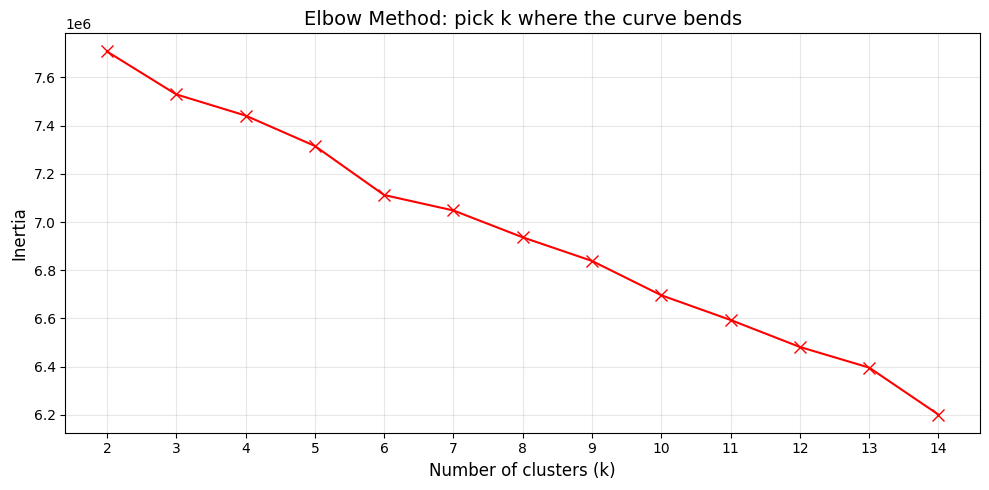

In [44]:
# Elbow method
print("Running elbow method")
inertias = []
k_range = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)
    print(f"  k={k} done")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), inertias, "-rx", markersize=8)
plt.xlabel("Number of clusters (k)", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.title("Elbow Method: pick k where the curve bends", fontsize=14)
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The elbow isn’t extremely sharp, which made the choice of k a bit subjective. I experimented with a few values before settling on six because it produced clusters that were easier to interpret visually.

## Trial 2: Dimensionality reduction

The MobileNet feature vectors are extremely large so I reduced them before plotting.

I first used PCA and then UMAP to produce a two dimensional embedding that could be visualised.

In [45]:
from sklearn.decomposition import PCA
import umap.umap_ as umap

# K-means clustering
k = 6
print(f"Clustering with k={k}")
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

# First reduce with PCA before UMAP
print("Running PCA firs")
pca = PCA(n_components=50, random_state=42)
features_pca = pca.fit_transform(features_scaled)
print(f"PCA reduced to shape: {features_pca.shape}")

# Then UMAP
print("Running UMAP")
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(features_pca)
print(f"UMAP embedding shape: {embedding.shape}")
print("Done.")

Clustering with k=6
Running PCA firs
PCA reduced to shape: (128, 50)
Running UMAP


/Users/miniconda3/envs/priyalconda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (128, 2)
Done.


## Trial 3: Visualising the clusters

After running K-means I plotted the logos in a few different ways.

First a UMAP map coloured by cluster.

Then the same map coloured by product category.

Finally a version where the actual logo images appear on the map.

Getting the thumbnail plot working took a bit of trial and error. The first few versions were basically unreadable because everything overlapped. I had to adjust the thumbnail size and label placement quite a bit.

???One thing I kept wondering while doing this was whether the model was actually picking up on meaningful visual features or just grouping logos by colour and brightness. It's hard to tell exactly what part of the image representation is driving the clusters.

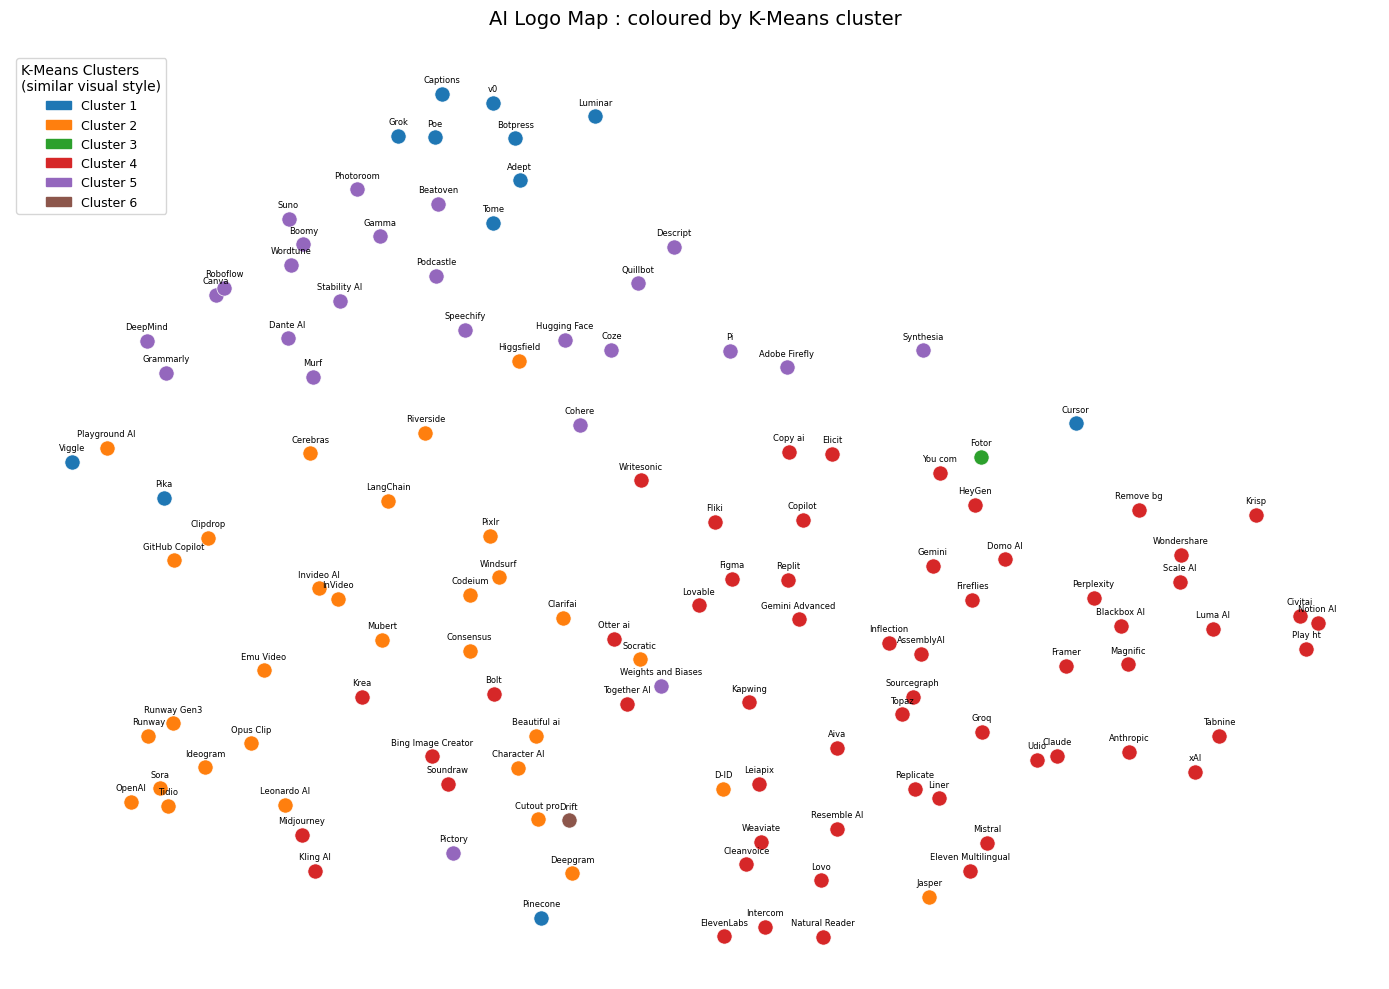

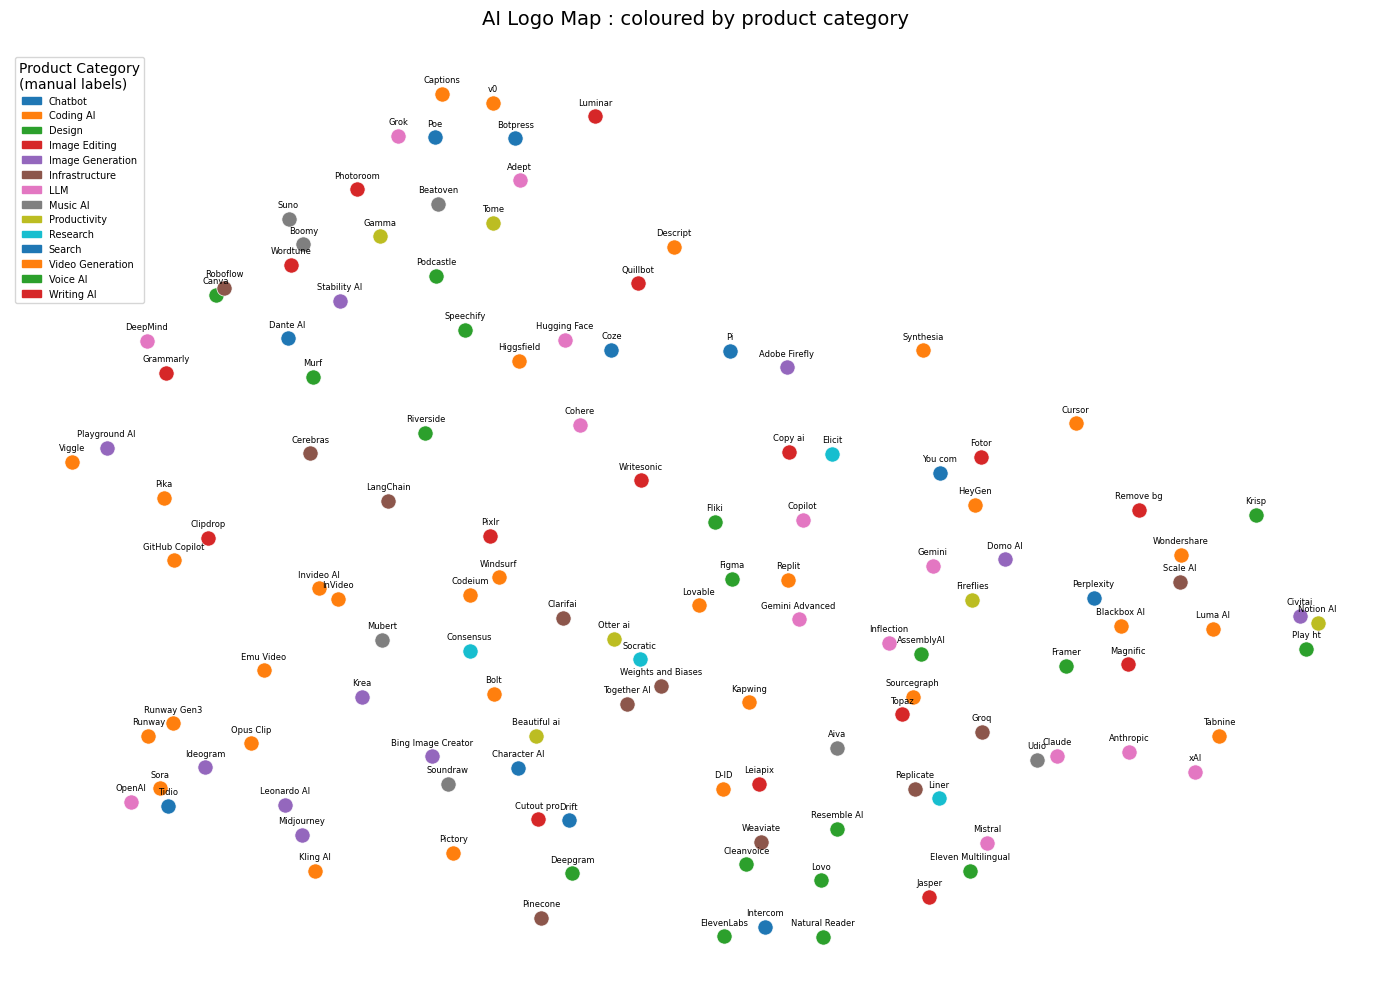

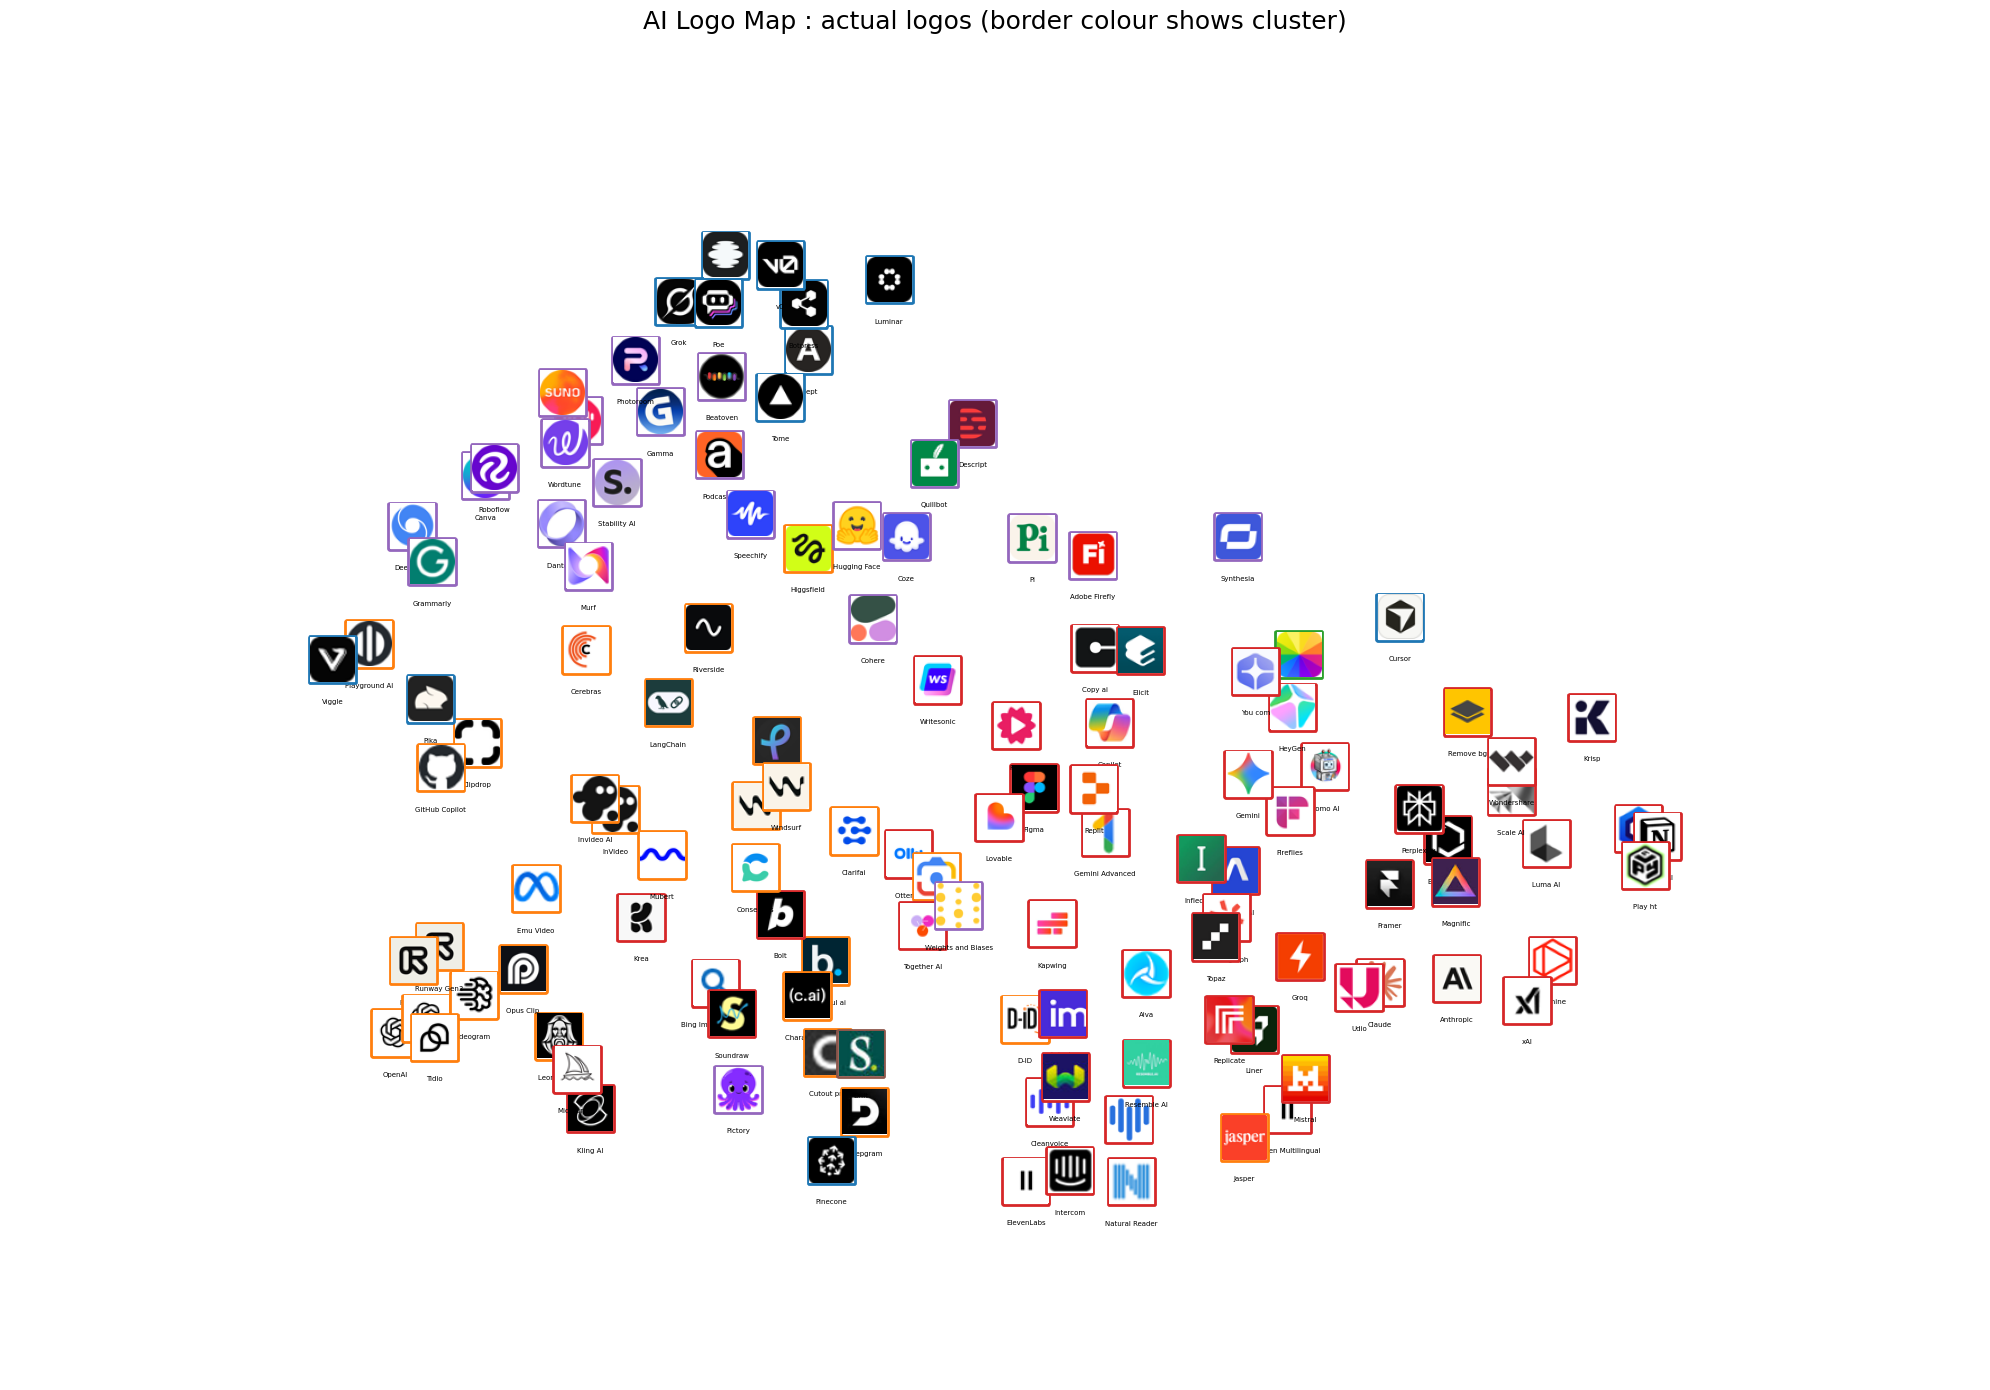

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

base_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

unique_categories = sorted(list(set(categories)))
category_colors = {cat: base_colors[i % len(base_colors)]
                  for i, cat in enumerate(unique_categories)}

cluster_colors = base_colors


# PLOT 1: coloured by CLUSTER
fig, ax = plt.subplots(figsize=(14, 10))

for i in range(len(names)):
    x, y = embedding[i]
    color = cluster_colors[cluster_labels[i] % len(cluster_colors)]

    ax.scatter(
        x, y,
        color=color,
        s=120,
        zorder=2,
        edgecolors="white",
        linewidth=0.5
    )

    ax.annotate(
        names[i],
        (x, y),
        fontsize=6,
        ha="center",
        va="bottom",
        xytext=(0, 7),
        textcoords="offset points"
    )

legend_elements = [
    mpatches.Patch(
        color=cluster_colors[i % len(cluster_colors)],
        label=f"Cluster {i+1}"
    )
    for i in range(k)
]

ax.legend(
    handles=legend_elements,
    title="K-Means Clusters\n(similar visual style)",
    loc="upper left",
    fontsize=9
)

ax.set_title(
    "AI Logo Map : coloured by K-Means cluster",
    fontsize=14,
    pad=20
)

ax.axis("off")

plt.tight_layout()
plt.show()


# PLOT 2: coloured by CATEGORY
fig, ax = plt.subplots(figsize=(14, 10))

for i in range(len(names)):
    x, y = embedding[i]
    color = category_colors[categories[i]]

    ax.scatter(
        x, y,
        color=color,
        s=120,
        zorder=2,
        edgecolors="white",
        linewidth=0.5
    )

    ax.annotate(
        names[i],
        (x, y),
        fontsize=6,
        ha="center",
        va="bottom",
        xytext=(0, 7),
        textcoords="offset points"
    )

legend_elements = [
    mpatches.Patch(
        color=category_colors[cat],
        label=cat
    )
    for cat in unique_categories
]

ax.legend(
    handles=legend_elements,
    title="Product Category\n(manual labels)",
    loc="upper left",
    fontsize=7,
    framealpha=0.8
)

ax.set_title(
    "AI Logo Map : coloured by product category",
    fontsize=14,
    pad=20
)

ax.axis("off")

plt.tight_layout()
plt.show()


# PLOT 3: logos with cluster borders
fig, ax = plt.subplots(figsize=(20, 14))

ax.set_xlim(embedding[:, 0].min() - 1, embedding[:, 0].max() + 1)
ax.set_ylim(embedding[:, 1].min() - 1, embedding[:, 1].max() + 1)

ax.axis("off")

ax.set_title(
    "AI Logo Map : actual logos (border colour shows cluster)",
    fontsize=18,
    pad=20
)

for i in range(len(names)):

    x, y = embedding[i]

    img = Image.open(image_paths[i]).convert("RGB")
    img = img.resize((40, 40))

    imagebox = OffsetImage(img, zoom=0.8)
    imagebox.image.axes = ax

    ab = AnnotationBbox(
        imagebox,
        (x, y),
        frameon=True,
        bboxprops=dict(
            boxstyle="round,pad=0.1",
            edgecolor=cluster_colors[cluster_labels[i] % len(cluster_colors)],
            linewidth=2
        )
    )

    ax.add_artist(ab)

    ax.annotate(
        names[i],
        (x, y),
        fontsize=5,
        ha="center",
        va="top",
        xytext=(0, -28),
        textcoords="offset points",
        color="black"
    )

plt.tight_layout()
plt.show()

## Trial 4: Comparing clusters with product categories

The most interesting comparison is between the cluster plot and the category plot.

If visual style matched product function the clusters and categories would roughly line up.

But they do not.

Most clusters contain logos from many different product types such as coding tools, voice AI systems, image generators and chat assistants.

In [47]:
print("CLUSTER CONTENTS\n")
for cluster_id in range(k):
    members = [(names[i], categories[i]) 
               for i in range(len(names)) 
               if cluster_labels[i] == cluster_id]
    print(f"CLUSTER {cluster_id + 1} — {len(members)} logos:")
    for name, cat in sorted(members):
        print(f"  {name} ({cat})")
    print()

CLUSTER CONTENTS

CLUSTER 1 — 12 logos:
  Adept (LLM)
  Botpress (Chatbot)
  Captions (Video Generation)
  Cursor (Coding AI)
  Grok (LLM)
  Luminar (Image Editing)
  Pika (Video Generation)
  Pinecone (Infrastructure)
  Poe (Chatbot)
  Tome (Productivity)
  Viggle (Video Generation)
  v0 (Coding AI)

CLUSTER 2 — 31 logos:
  Beautiful ai (Productivity)
  Cerebras (Infrastructure)
  Character AI (Chatbot)
  Clarifai (Infrastructure)
  Clipdrop (Image Editing)
  Codeium (Coding AI)
  Consensus (Research)
  Cutout pro (Image Editing)
  D-ID (Video Generation)
  Deepgram (Voice AI)
  Emu Video (Video Generation)
  GitHub Copilot (Coding AI)
  Higgsfield (Video Generation)
  Ideogram (Image Generation)
  InVideo (Video Generation)
  Invideo AI (Video Generation)
  Jasper (Writing AI)
  LangChain (Infrastructure)
  Leonardo AI (Image Generation)
  Mubert (Music AI)
  OpenAI (LLM)
  Opus Clip (Video Generation)
  Pixlr (Image Editing)
  Playground AI (Image Generation)
  Riverside (Voice AI)


In [48]:
from collections import Counter

print("CLUSTER CONVERGENCE ANALYSIS\n")
for cluster_id in range(k):
    members = [(names[i], categories[i]) 
               for i in range(len(names)) 
               if cluster_labels[i] == cluster_id]
    cat_counts = Counter(cat for _, cat in members)
    dominant_cat, dominant_n = cat_counts.most_common(1)[0]
    purity = dominant_n / len(members)
    n_cats = len(cat_counts)
    
    print(f"Cluster {cluster_id+1}: {len(members)} logos, "
          f"{n_cats} categories, "
          f"purity={purity:.0%} "
          f"(dominant: {dominant_cat})")

CLUSTER CONVERGENCE ANALYSIS

Cluster 1: 12 logos, 7 categories, purity=25% (dominant: Video Generation)
Cluster 2: 31 logos, 12 categories, purity=29% (dominant: Video Generation)
Cluster 3: 1 logos, 1 categories, purity=100% (dominant: Image Editing)
Cluster 4: 58 logos, 14 categories, purity=17% (dominant: Voice AI)
Cluster 5: 25 logos, 11 categories, purity=12% (dominant: Music AI)
Cluster 6: 1 logos, 1 categories, purity=100% (dominant: Chatbot)


Interestingly two clusters are both dominated by video generation companies. This does not mean the algorithm is grouping logos by product function. It likely reflects the fact that video AI companies themselves use multiple visual styles...

## Trial 5: Quantifying how mixed the clusters are

Visually, the clusters already looked quite mixed. Many of them contained logos from several different product categories.

To make this observation more concrete, I calculated cluster purity to measure how dominant the most common category is inside each cluster.

If clusters were strongly aligned with product function, we would expect purity to be very high, close to 100%.
If clusters contain many different categories, purity will be much lower.

The plot is supposed to visualize two things:

- the UMAP map with cluster labels and purity values
- a bar chart summarising the purity of each cluster

For reference, I also added a random baseline. With 14 product categories, random grouping would produce about "7% purity" on average.

In [49]:
from collections import Counter

cluster_dominant = {}

for cid in range(k):
    members = [categories[i] for i in range(len(names)) if cluster_labels[i] == cid]
    
    if len(members) > 0:
        dominant = Counter(members).most_common(1)[0][0]
        cluster_dominant[cid] = dominant
    else:
        cluster_dominant[cid] = "Unknown"

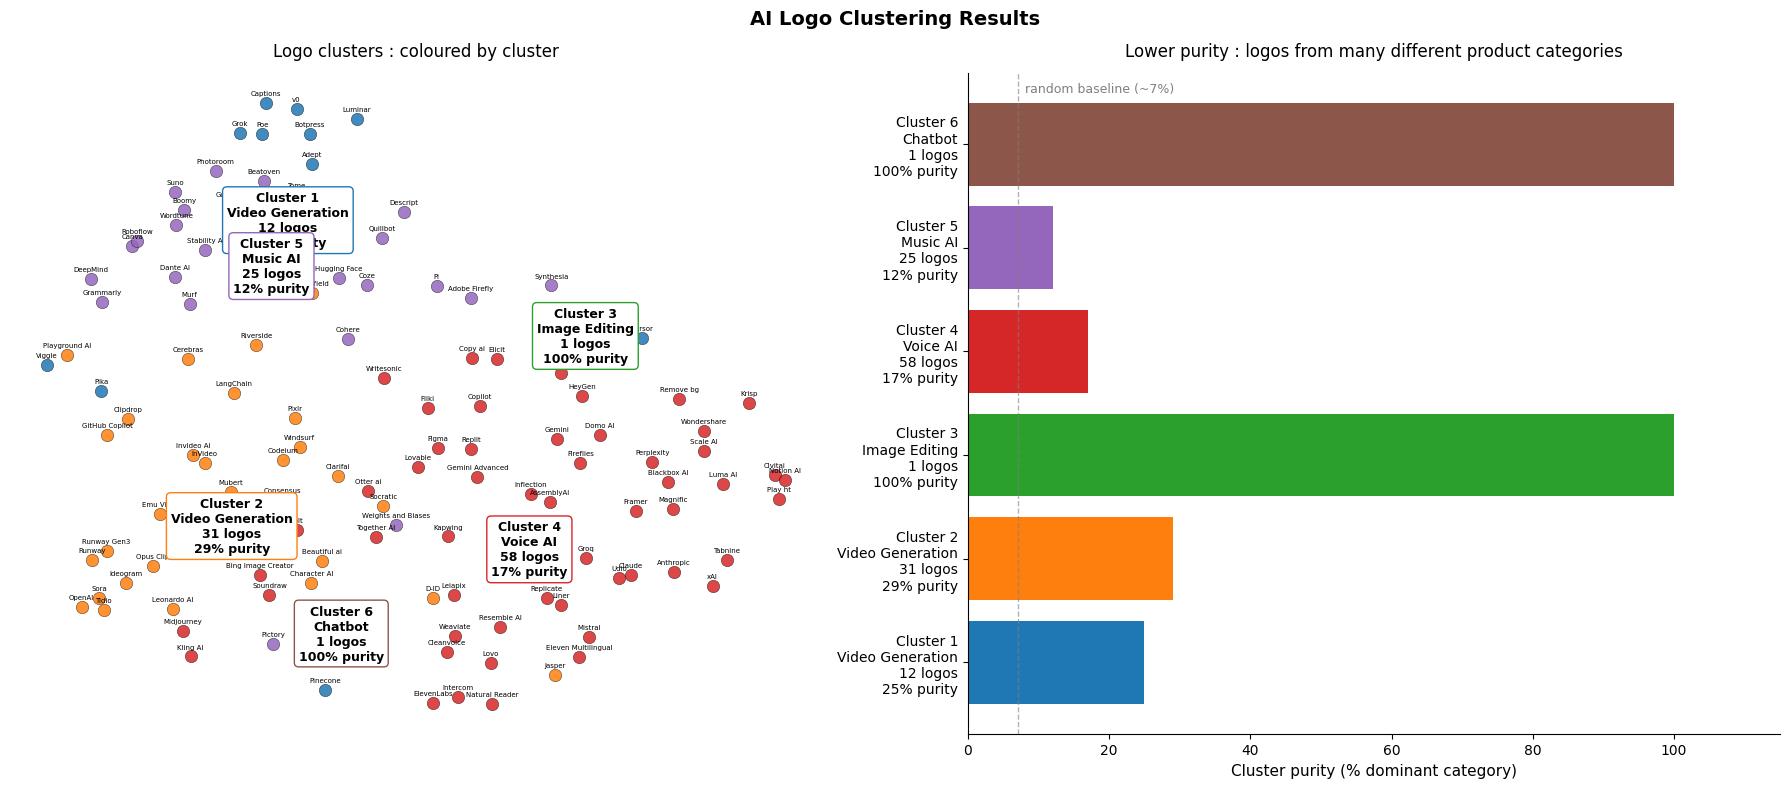

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Use matplotlib default color cycle (same as Week 3)
cluster_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Compute dominant category per cluster
cluster_dominant = {}

for cid in range(k):
    members = [categories[i] for i in range(len(names)) if cluster_labels[i] == cid]
    
    if len(members) > 0:
        dominant = Counter(members).most_common(1)[0][0]
        cluster_dominant[cid] = dominant
    else:
        cluster_dominant[cid] = "Unknown"


# LEFT: UMAP coloured by cluster
ax = axes[0]

for i in range(len(names)):
    x, y = embedding[i]
    color = cluster_colors[cluster_labels[i] % len(cluster_colors)]
    
    ax.scatter(
        x, y,
        color=color,
        s=80,
        edgecolors="black",
        linewidth=0.3,
        alpha=0.85
    )
    
    ax.annotate(
        names[i],
        (x, y),
        fontsize=5,
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points"
    )


# Cluster purity and sizes
cluster_purities = [25, 29, 100, 17, 12, 100]
cluster_sizes = [12, 31, 1, 58, 25, 1]

# Offsets to avoid overlapping labels
label_offsets = [0.15, -0.15, 0.2, -0.2, 0.1, -0.1]

for cid in range(k):

    xs = [embedding[i][0] for i in range(len(names)) if cluster_labels[i] == cid]
    ys = [embedding[i][1] for i in range(len(names)) if cluster_labels[i] == cid]

    cx, cy = np.mean(xs), np.mean(ys)
    cy += label_offsets[cid]

    ax.text(
        cx,
        cy,
        f"Cluster {cid+1}\n{cluster_dominant[cid]}\n{cluster_sizes[cid]} logos\n{cluster_purities[cid]}% purity",
        fontsize=9,
        color="black",
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor=cluster_colors[cid % len(cluster_colors)],
            linewidth=1
        )
    )

ax.set_title(
    "Logo clusters : coloured by cluster",
    fontsize=12,
    pad=12
)

ax.axis("off")


# RIGHT: Cluster purity bar chart
ax2 = axes[1]

cluster_labels_names = [
    f"Cluster {i+1}\n{cluster_dominant[i]}\n{cluster_sizes[i]} logos\n{cluster_purities[i]}% purity"
    for i in range(k)
]

bars = ax2.barh(
    cluster_labels_names,
    cluster_purities,
    color=[cluster_colors[i % len(cluster_colors)] for i in range(k)],
    edgecolor="none",
    height=0.8
)

# Random baseline
random_baseline = 100 / 14

ax2.axvline(
    x=random_baseline,
    linestyle="--",
    linewidth=1,
    color="gray",
    alpha=0.6
)

ax2.text(
    random_baseline + 1,
    k - 0.5,
    "random baseline (~7%)",
    fontsize=9,
    color="gray"
)

ax2.set_xlim(0, 115)

ax2.set_xlabel(
    "Cluster purity (% dominant category)",
    fontsize=11
)

ax2.set_title(
    "Lower purity : logos from many different product categories",
    fontsize=12,
    pad=12
)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle(
    "AI Logo Clustering Results",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Reflection

After running the clustering and looking at the plots the main thing that stood out is that logos tend to group together because they 'look similar', not because the companies build the same type of product.

Some clusters contain logos from coding tools, voice AI systems, image generators and chat assistants all mixed together. I originally expected categories like image generation or coding tools to form clearer groups but that did not really happen.

Instead the clusters mostly reflect a shared visual style. Gradients, abstract shapes and similar colour palettes appear across many companies. So at least in this dataset, visual style seems to matter more than product function when logos are grouped by appearance.

Of course there are several limitations here. The dataset is relatively small and the logos were collected manually so image quality varies. MobileNet was also trained on natural photographs rather than logos, so the features it extracts may not be ideal for this kind of data. Another possibility is that the clustering is driven heavily by colour, since many AI logos use similar blue and purple gradients.

Even with those limitations this was still a fun experiment. The project started from something very informal which was basically a meme about AI logos, but mapping the logos together made the visual similarity much easier to see.

If I continue this project further I would probably expand the dataset and turn it into a small project exploring design trends in AI branding. It would also be interesting to compare AI logos with logos from other tech sectors to see whether this visual convergence is specific to AI or part of a broader design trend.

## LLM Disclaimer

One place where LLM's really helped was figuring out how to extract favicons using the Google favicon API so I could build the logo dataset automatically instead of downloading everything manually.

I also used it while working with MobileNet in PyTorch, mainly to understand how to remove the final classification layer and use the network as a feature extractor.
Some of the documentation assumes you are already familiar with the PyTorch workflow, so it helped to see simpler explanations when I got stuck.